# Argentine Senate floor speech, 2000–2024

Analysis of the ar_congress corpus: 559 stenographic session transcripts
(versiones taquigráficas) published by the Senado de la Nación, parsed into
speaker-attributed speech turns and typed stenographer events (parser
0.4.6), with speakers resolved to persons. Provenance and terms:
[SOURCES.md](../SOURCES.md).

In [1]:
import unicodedata
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
BLOCKS = ROOT / "data" / "processed" / "senado" / "blocks"

corpus = pd.concat([pd.read_parquet(p) for p in sorted(BLOCKS.glob("*.parquet"))], ignore_index=True)
speakers = pd.read_parquet(ROOT / "data" / "processed" / "senado" / "speakers.parquet")

speech = corpus[corpus.type == "speech"].merge(
    speakers[["session_id", "speaker_raw", "person_id", "person_name", "party_or_alliance", "province", "match_status"]],
    on=["session_id", "speaker_raw"], how="left",
)
speech["words"] = speech.text.str.split().str.len()
speech["year"] = speech.session_date.str[:4].astype(int)
corpus["year"] = corpus.session_date.str[:4].astype(int)

# The portal lists these years but no longer serves most of the files, so
# their totals are a floor on what was said, not a measurement of it.
PARTIAL_YEARS = range(2000, 2004)

print(f"{corpus.session_id.nunique()} sessions | {len(corpus):,} rows | "
      f"{len(speech):,} speech turns | {speech.words.sum():,} words spoken")

/var/folders/ht/hrj3dkvj36g0wrcz5phcdv580000gn/T/ipykernel_79746/121175720.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corpus = pd.concat([pd.read_parquet(p) for p in sorted(BLOCKS.glob("*.parquet"))], ignore_index=True)


558 sessions | 257,798 rows | 154,794 speech turns | 18,008,738 words spoken


## Sampling frame — read this before trusting any trend

The corpus is **not** a neutral sample of Senate activity, and two of the
distortions are large enough to invent trends on their own:

- **2000–2003 is thin, and not because the chamber was quiet.** The portal
  lists those sittings but no longer serves most of the files: 3 of 75
  sessions held for 2000, 10 of 83 for 2001, 4 of 47 for 2002, 34 of 47 for
  2003. From 2004 on, every session the portal lists is held. Any per-year
  total before 2004 is a floor, not a measurement — the charts below mark
  those years and the rate chart drops them.
- **Session counts swing with the political calendar**, from 46 sittings in
  2005 to 12 in the 2023 election year, so a fall in yearly word totals can
  mean fewer sittings rather than less speech. Both are shown separately.
- **Asambleas Legislativas are not Senate debate** — they are joint sittings
  where the President of the Nation speaks. They stay in the corpus but are
  excluded from every floor-speech figure here.
- **Alliance ≠ caucus.** The roster records the *electoral alliance* each
  senator was elected under, not the bloc they sat with. The two diverge
  sharply after 2015: radicals elected on Cambiemos and Juntos por el Cambio
  tickets appear under those labels and not under the UCR, which is why the
  groupings below put the UCR and the coalitions built around it together.

In [2]:
overview = (corpus.groupby(["year", "session_type"]).session_id.nunique()
            .unstack(fill_value=0))
overview["total"] = overview.sum(axis=1)
overview

session_type,ASAMBLEA,EN MINORÍA,ESPECIAL,ESPECIAL EN MINORÍA,ESPECIAL EXTRAORDINARIA,EXTRAORDINARIA,INFORMATIVA ESPECIAL,ORDINARIA,ORDINARIA CONTINUACIÓN,PREPARATORIA,REUNIÓN CONJ.AMBAS CÁMARAS,TRIBUNAL DE JUICIO POLITICO,total
year,,,,,,,,,,,,,
2000,1,0,1,0,0,0,0,0,0,1,0,0,3
2001,0,3,0,0,0,0,0,6,0,1,0,0,10
2002,0,3,1,0,0,0,0,0,0,0,0,0,4
2003,4,0,2,0,0,0,0,16,0,0,0,12,34
2004,2,1,3,0,0,1,0,30,0,1,0,2,40
2005,1,0,2,0,0,5,0,24,0,1,0,13,46
2006,2,0,2,0,0,2,0,29,0,1,0,0,36
2007,3,0,1,0,0,1,0,20,0,1,0,0,26
2008,3,0,0,0,0,2,1,22,0,1,0,0,29


## Who holds the floor?

**Floor speech** here means: speech turns by senators speaking from the
floor (`match_status == "matched_senator"`), outside Asambleas. Chair and
officer speech is excluded as procedural — the presiding officer's "Tiene
la palabra..." traffic would otherwise swamp every signal.

Alliances are grouped into four **party families** by the keyword rules in
the next cell — auditable and deliberately coarse, so that one bucket can
hold a party and the coalitions it later ran inside. Provincial alliances
(Movimiento Popular Neuquino, Cruzada Renovadora de San Juan, Juntos Somos
Río Negro, ...) stay in their own bucket even where their senators caucus
with a national bloc.

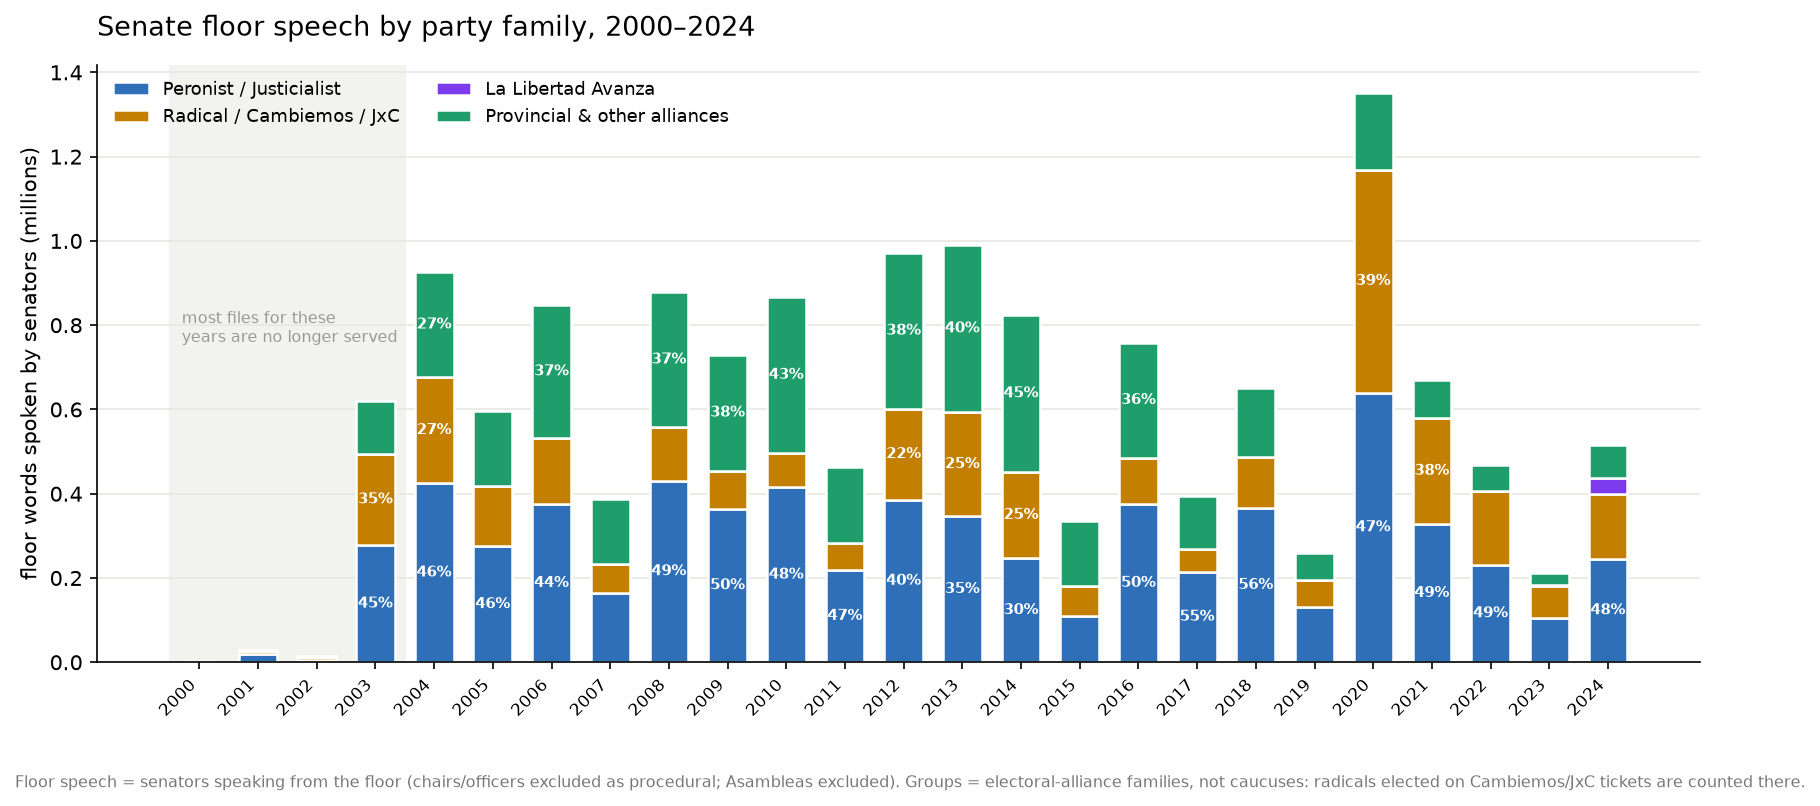

family,Peronist / Justicialist,Radical / Cambiemos / JxC,La Libertad Avanza,Provincial & other alliances
year,,,,
2000,0.001,0.000,0.000,0.000
2001,0.019,0.008,0.000,0.003
2002,0.005,0.007,0.000,0.003
2003,0.278,0.217,0.000,0.124
2004,0.425,0.251,0.000,0.250
2005,0.275,0.142,0.000,0.180
2006,0.375,0.157,0.000,0.315
2007,0.164,0.068,0.000,0.154
2008,0.431,0.126,0.000,0.322


In [3]:
def deaccent(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if not unicodedata.combining(c))

def family(alliance):
    """Group an electoral-alliance label into a party family.

    Order matters: the era-specific coalition labels are tested first, so a
    radical elected on a Cambiemos ticket lands with Cambiemos — which is
    what the ballot said — rather than with the UCR.
    """
    a = deaccent(str(alliance or "")).upper()
    if "LIBERTAD AVANZA" in a:
        return "La Libertad Avanza"
    if "CAMBIEMOS" in a or "JUNTOS POR EL CAMBIO" in a or "CIVICA RADICAL" in a or "UCR" in a:
        return "Radical / Cambiemos / JxC"
    if any(k in a for k in ("JUSTICIALIS", "PERONIS", "PARA LA VICTORIA", "DE LA VICTORIA",
                            "P/VICTORIA", "DE TODOS", "UNIDAD CIUDADANA", "UNION POR LA PATRIA")):
        return "Peronist / Justicialist"
    return "Provincial & other alliances"

floor = speech[(speech.match_status == "matched_senator") & (speech.session_type != "ASAMBLEA")].copy()
floor["family"] = floor.party_or_alliance.map(family)

ORDER = ["Peronist / Justicialist", "Radical / Cambiemos / JxC",
         "La Libertad Avanza", "Provincial & other alliances"]
COLORS = {"Peronist / Justicialist": "#2E6FB8", "Radical / Cambiemos / JxC": "#C27F00",
          "La Libertad Avanza": "#7C3AED", "Provincial & other alliances": "#1F9D6B"}

by_year = (floor.groupby(["year", "family"]).words.sum().unstack(fill_value=0)
           .reindex(columns=ORDER, fill_value=0) / 1e6)

fig, ax = plt.subplots(figsize=(11.5, 5.0), dpi=150)
ax.axvspan(min(PARTIAL_YEARS) - 0.5, max(PARTIAL_YEARS) + 0.5, color="#f2f2ef", zorder=0)
ax.text(min(PARTIAL_YEARS) - 0.30, by_year.sum(axis=1).max() * 0.62,
        "most files for these\nyears are no longer served",
        fontsize=7.5, color="#999999", va="top")

bottom = pd.Series(0.0, index=by_year.index)
for col in ORDER:
    ax.bar(by_year.index, by_year[col], bottom=bottom, width=0.66,
           color=COLORS[col], edgecolor="white", linewidth=1.2, label=col, zorder=2)
    seg = by_year[col]
    for x, (y0, h) in zip(by_year.index, zip(bottom, seg)):
        if h > 0.14 * by_year.sum(axis=1).max():
            ax.text(x, y0 + h / 2, f"{h / by_year.sum(axis=1)[x]:.0%}", ha="center", va="center",
                    color="white", fontsize=7, fontweight="bold", zorder=3)
    bottom += seg

ax.set_title("Senate floor speech by party family, 2000–2024",
             fontsize=13, loc="left", pad=14)
ax.set_ylabel("floor words spoken by senators (millions)")
ax.set_xticks(list(by_year.index))
ax.set_xticklabels(by_year.index, rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f"))
ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper left", ncol=2)
fig.text(0.01, -0.06,
         "Floor speech = senators speaking from the floor (chairs/officers excluded as procedural; Asambleas excluded). "
         "Groups = electoral-alliance families, not caucuses: radicals elected on Cambiemos/JxC tickets are counted there.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "floor_words_by_year.png", bbox_inches="tight")
plt.show()

by_year.round(3)

## Fewer sittings, or shorter ones?

A yearly total mixes two different things: how often the chamber sat and
how much was said when it did. Separating them changes the reading of the
2020–2023 fall — and shows that 2020, the remote-procedure year, was
extraordinary in the number of sittings rather than in their length.

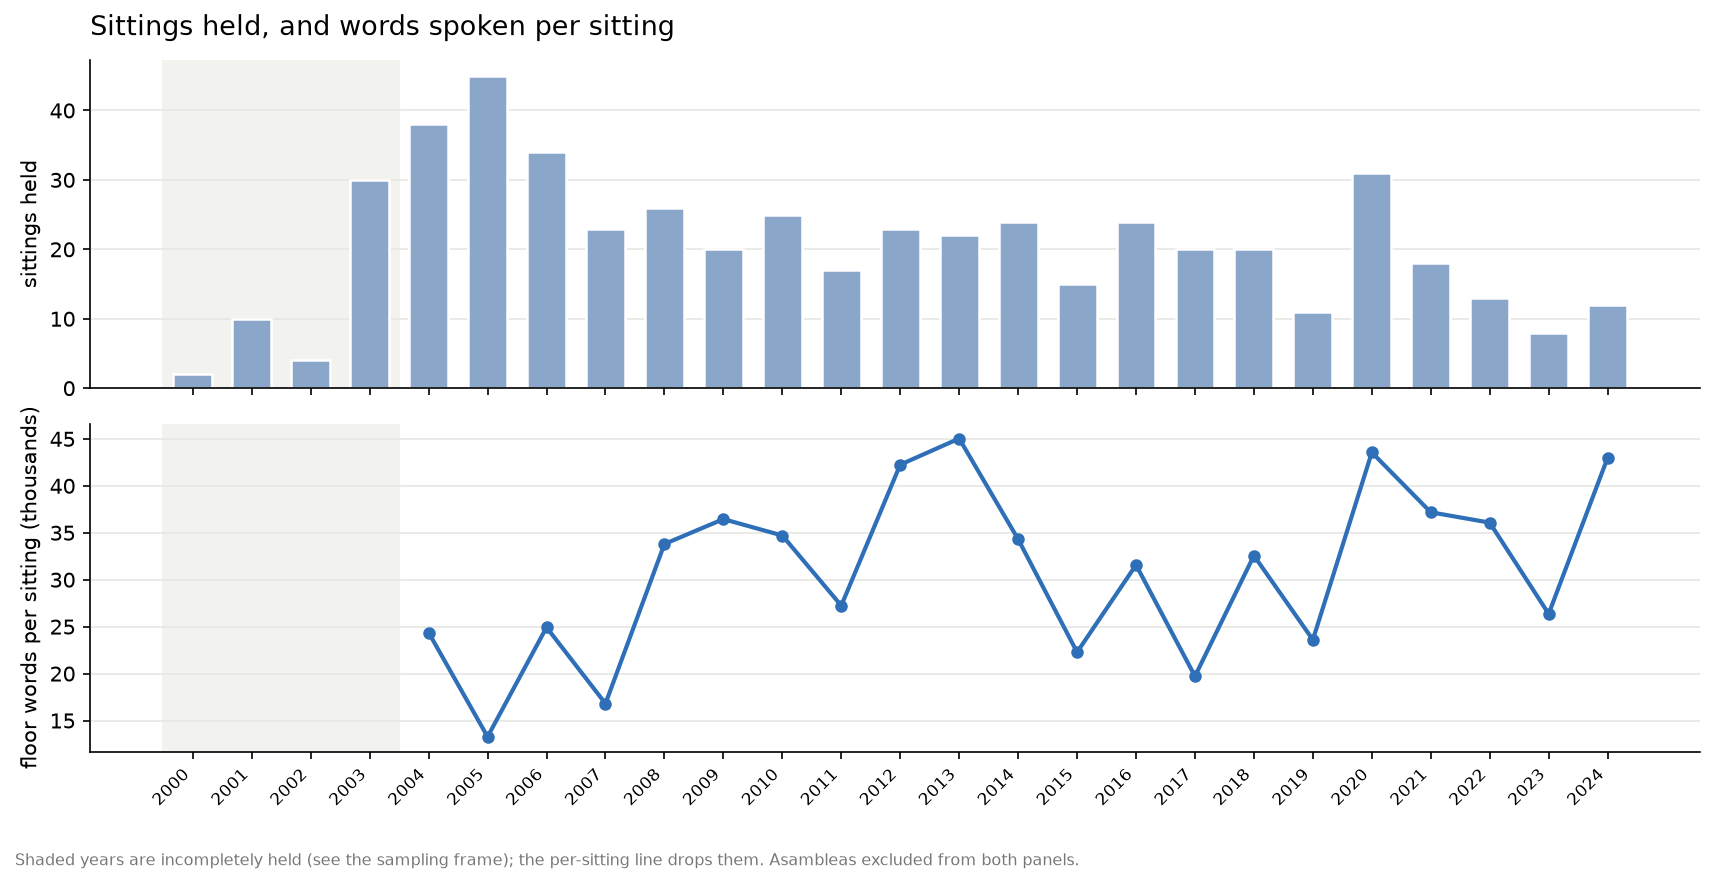

year,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
sittings,2.0,10.0,4.0,30.0,38.0,45.0,34.0,23.0,26.0,20.0,...,15.0,24.0,20.0,20.0,11.0,31.0,18.0,13.0,8.0,12.0
words per sitting,806.0,2962.0,3771.0,20632.0,24371.0,13274.0,24927.0,16806.0,33802.0,36454.0,...,22279.0,31573.0,19722.0,32571.0,23603.0,43556.0,37182.0,36080.0,26363.0,42986.0


In [4]:
sessions_held = (corpus[corpus.session_type != "ASAMBLEA"]
                 .groupby("year").session_id.nunique())
words_year = floor.groupby("year").words.sum()
per_session = (words_year / sessions_held).dropna()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 5.6), dpi=150, sharex=True)
full = [y for y in per_session.index if y not in PARTIAL_YEARS]

ax1.bar(sessions_held.index, sessions_held.values, width=0.66, color="#8AA6C8",
        edgecolor="white", linewidth=1.2)
ax1.set_ylabel("sittings held")
ax1.set_title("Sittings held, and words spoken per sitting", fontsize=13, loc="left", pad=12)

ax2.plot(full, per_session.reindex(full).values / 1000, marker="o", markersize=5,
         linewidth=2, color="#2E6FB8")
ax2.set_ylabel("floor words per sitting (thousands)")
ax2.set_xticks(list(sessions_held.index))
ax2.set_xticklabels(sessions_held.index, rotation=45, ha="right", fontsize=8)

for ax in (ax1, ax2):
    ax.axvspan(min(PARTIAL_YEARS) - 0.5, max(PARTIAL_YEARS) + 0.5, color="#f2f2ef", zorder=0)
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.text(0.01, -0.04,
         "Shaded years are incompletely held (see the sampling frame); the per-sitting line drops them. Asambleas excluded from both panels.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "sittings_and_length.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"sittings": sessions_held, "words per sitting": per_session.round(0)}).T

## Chamber temperature

The stenographer events the parser preserves allow something
transcripts-as-text cannot: measuring what happened *around* the words.
Rates are per 10,000 floor words, so a quiet year does not masquerade as a
calm one. The incompletely held years are dropped — a few thousand words
make the denominator too thin to divide by.

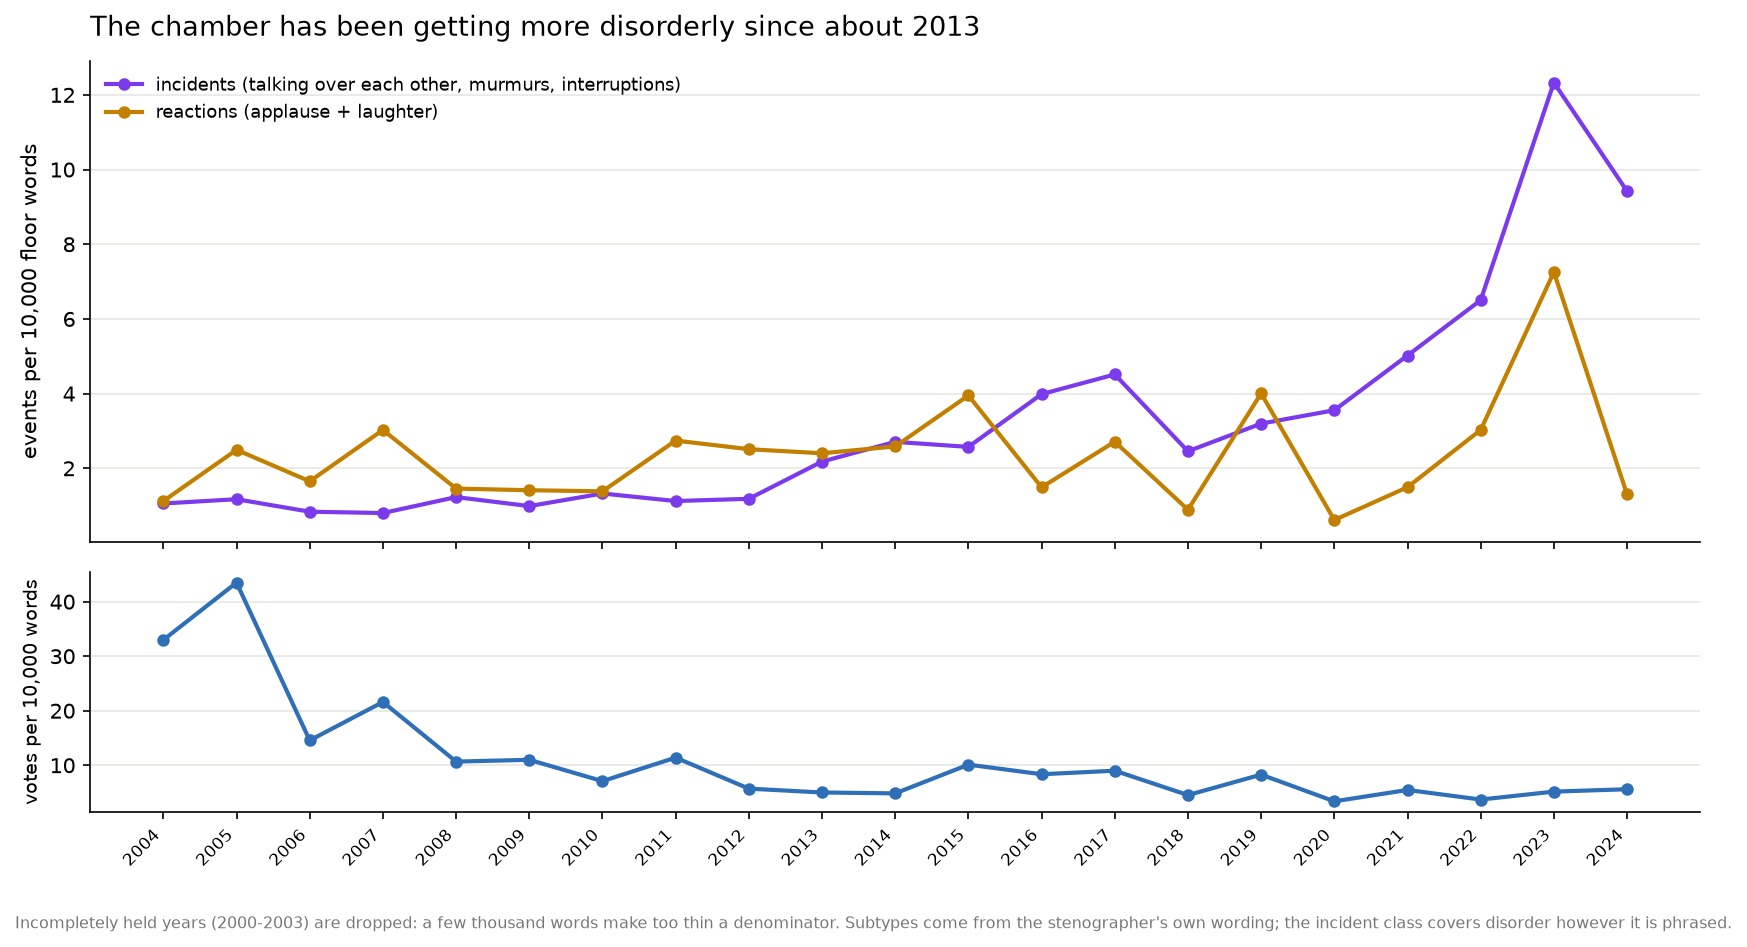

,incidents,reactions,votes
year,,,
2004,1.1,1.1,33.0
2005,1.2,2.5,43.5
2006,0.8,1.7,14.6
2007,0.8,3.0,21.6
2008,1.2,1.5,10.7
2009,1.0,1.4,11.0
2010,1.3,1.4,7.1
2011,1.1,2.7,11.4
2012,1.2,2.5,5.7


In [5]:
events = corpus[(corpus.type == "event") & (corpus.session_type != "ASAMBLEA")]
fw = floor.groupby("year").words.sum()
fw = fw[[y for y in fw.index if y not in PARTIAL_YEARS]]

def rate(subtypes):
    n = events[events.event_type.isin(subtypes)].groupby("year").size()
    return (n / fw * 10_000).reindex(fw.index)

# Votes sit an order of magnitude above the rest and would flatten them on a
# shared axis, so they get their own panel: procedural volume, not temperature.
TEMP = {"incidents (talking over each other, murmurs, interruptions)": (["incident"], "#7C3AED"),
        "reactions (applause + laughter)": (["applause", "laughter"], "#C27F00")}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11.5, 6.0), dpi=150, sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
for name, (subtypes, colour) in TEMP.items():
    r = rate(subtypes)
    ax1.plot(r.index, r.values, marker="o", markersize=5, linewidth=2, color=colour, label=name)
ax1.set_ylabel("events per 10,000 floor words")
ax1.set_title("The chamber has been getting more disorderly since about 2013",
              fontsize=13, loc="left", pad=12)
ax1.legend(frameon=False, fontsize=8.5, loc="upper left")

votes = rate(["vote"])
ax2.plot(votes.index, votes.values, marker="o", markersize=5, linewidth=2, color="#2E6FB8")
ax2.set_ylabel("votes per 10,000 words", fontsize=9)
ax2.set_xticks(list(fw.index))
ax2.set_xticklabels(fw.index, rotation=45, ha="right", fontsize=8)

for ax in (ax1, ax2):
    ax.grid(axis="y", color="#e6e6e3", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
fig.text(0.01, -0.04,
         "Incompletely held years (2000-2003) are dropped: a few thousand words make too thin a denominator. "
         "Subtypes come from the stenographer's own wording; the incident class covers disorder however it is phrased.",
         fontsize=7.5, color="#777777")
fig.tight_layout()
fig.savefig(ROOT / "figures" / "chamber_temperature.png", bbox_inches="tight")
plt.show()

pd.DataFrame({"incidents": rate(["incident"]), "reactions": rate(["applause", "laughter"]),
              "votes": votes}).round(1)

## Who spoke most, over twenty-five years

In [6]:
span = floor.groupby("person_name").year.agg(["min", "max"])
top = (floor.groupby(["person_name", "province"]).words.sum()
       .sort_values(ascending=False).head(15) / 1000).round(1).rename("floor words (thousands)")
top = top.reset_index().merge(span, left_on="person_name", right_index=True)
top["years on the floor"] = top["min"].astype(str) + "–" + top["max"].astype(str)
top[["person_name", "province", "floor words (thousands)", "years on the floor"]]

,person_name,province,floor words (thousands),years on the floor
0,"MORALES, GERARDO RUBÉN",JUJUY,747.5,2002–2015
1,"PICHETTO, MIGUEL ÁNGEL",RÍO NEGRO,733.7,2001–2019
2,"MAYANS, JOSÉ MIGUEL ÁNGEL",FORMOSA,476.0,2002–2024
3,"NEGRE DE ALONSO, LILIANA TERESITA",SAN LUIS,451.6,2001–2017
4,"PETCOFF NAIDENOFF, LUIS CARLOS",FORMOSA,436.6,2005–2023
5,"SANZ, ERNESTO RICARDO",MENDOZA,390.2,2003–2015
6,"GIUSTINIANI, RUBÉN HÉCTOR",SANTA FE,378.9,2003–2015
7,"RODRÍGUEZ SAÁ, ADOLFO",SAN LUIS,294.3,2005–2023
8,"ESCUDERO, SONIA MARGARITA",SALTA,291.3,2001–2013
9,"ROMERO, JUAN CARLOS",SALTA,273.7,2007–2024


## Findings

1. **The Peronist/Justicialist family has been the largest on the floor in
   every fully held year.** Its share of floor words runs from 30% to 56%,
   median 48%, across four changes of national government. It is never a
   majority and never below three in ten.
2. **What moved is the labels everyone else ran under.** Provincial and
   other alliances held 36–46% of floor words from 2006 to 2016 and 13–15%
   from 2020 on, while the radical/Cambiemos family went the other way
   (9–25% before 2019, 30–39% after). Senators did not all change sides:
   the tickets they were elected on consolidated into two national
   coalitions. This is the alliance-is-not-caucus caveat made visible, and
   it is the strongest reason not to read these bars as bloc strength.
3. **The 2020–2023 collapse was mostly fewer sittings, not quieter ones.**
   Floor words fell 6.4-fold, but that splits into a 3.9-fold fall in
   sittings held (31 to 8, Asambleas excluded) and only a 1.65-fold fall in
   words per sitting. By 2024 a sitting was as long as ever — 43,000 floor
   words, in line with 2013's 45,000 — there were simply twelve of them.
4. **The chamber has been getting steadily more disorderly since about
   2013.** Recorded incidents per 10,000 floor words ran near 1 through the
   2000s, reached 2.2 by 2013, 4.0–4.5 in 2016–2017, 5.0–6.5 in 2021–2022,
   and peaked at 12.3 in 2023 before easing to 9.4 in 2024 — roughly a
   tenfold rise across the span. It begins well before the remote sittings
   of 2020, so it is not an artefact of them.
5. **Floor time follows leadership, not province size.** The most talkative
   senators of the span are bloc chiefs and party leaders — Gerardo Morales
   (Jujuy, 748k words), Miguel Ángel Pichetto (Río Negro, 734k), José
   Mayans (Formosa, 476k) — not the senators of the largest provinces.

**Caveats carried from the sampling frame:** incomplete holdings before
2004, session-type mix, alliance-family grouping (not caucus),
chairs/officers excluded. **Next:** caucus mapping for departed senators,
and the Cámara de Diputados.